<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/GAN_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#%pip install torch matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Hyper Parameters

In [3]:
batch_size = 64
latent_dim = 5
epochs = 2000
lr = 0.0002

# Real data distribution (Gaussian)
def sample_real(batch_size):
    return torch.randn(batch_size, 1) * 1.5 + 4

# Generator

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, z):
        return self.net(z)

# Discriminator

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
G = Generator()
D = Discriminator()

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G.to(device)
D.to(device)
criterion.to(device)

BCELoss()

# Training Loop

In [8]:
G.train()
D.train()

for epoch in range(epochs):

    # ---- Train Discriminator ----
    real_data = sample_real(batch_size).to(device)
    real_labels = torch.ones(batch_size, 1).to(device)

    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    real_loss = criterion(D(real_data), real_labels)
    fake_loss = criterion(D(fake_data.detach()), fake_labels)

    d_loss = real_loss + fake_loss

    opt_D.zero_grad()
    d_loss.backward()
    opt_D.step()

    # ---- Train Generator ----
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)

    g_loss = criterion(D(fake_data), real_labels)

    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 0.8511 | G Loss: 0.6759
Epoch 200 | D Loss: 0.7011 | G Loss: 0.7981
Epoch 400 | D Loss: 0.6427 | G Loss: 0.8828
Epoch 600 | D Loss: 0.6096 | G Loss: 0.8061
Epoch 800 | D Loss: 0.7777 | G Loss: 0.8164
Epoch 1000 | D Loss: 0.9416 | G Loss: 0.8396
Epoch 1200 | D Loss: 1.1314 | G Loss: 0.7940
Epoch 1400 | D Loss: 1.2773 | G Loss: 0.8393
Epoch 1600 | D Loss: 1.4613 | G Loss: 0.7865
Epoch 1800 | D Loss: 1.4889 | G Loss: 0.8000


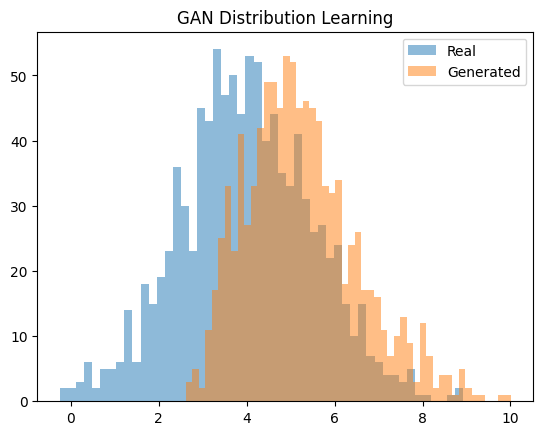

In [12]:
real_samples = sample_real(1000).detach().numpy()
z = torch.randn(1000, latent_dim).to(device)
fake_samples = G(z).cpu().detach().numpy()

plt.hist(real_samples, bins=50, alpha=0.5, label="Real")
plt.hist(fake_samples, bins=50, alpha=0.5, label="Generated")
plt.legend()
plt.title("GAN Distribution Learning")
plt.show()